# Incremental genetic predictability beyond ZeBRA

This notebook tests whether SNP variation adds predictive information beyond the ZeBRA `predicted_risk` score for adjudicated fibrotic ILD / fibrotic ILA.

The primary stacked model is

\[
\operatorname{logit}P(Y=1)
=
\beta_0
+\beta_Z\,\operatorname{logit}(Z_{\mathrm{ZeBRA}})
+\beta_G\,G
+\beta_{ZG}\,\operatorname{logit}(Z_{\mathrm{ZeBRA}})\,G ,
\]

where \(G\) is a learned polygenic score (PRS-like linear predictor) derived from SNP dosages.

### Leakage control

1. A final test set is held out before any model fitting.
2. The genetic score for development-set patients is generated **out-of-fold**.
3. The final genetic model is fit on the full development set and applied once to the held-out test set.
4. Thresholds for fixed-FPR analyses are selected on development data, not on the test set.
5. ZeBRA-only and combined models are evaluated on **exactly the same test patients**.

The notebook expects the same files used by the existing `ZEBRA_GENDRIVERS_CLASSIFIER` notebooks:

- `ILD_TOP_DRIVERS_DATA.csv`
- `REPHENOTYPES FOR IC.csv`
- `PREDICTIONS_104W_PRED_WINDOW.parquet`

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 1321
TARGET_NAME = "FILD or FILA ADJUDICATED"

TEST_SIZE = 0.25
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 4
N_BOOT = 2000
FPR_LEVELS = [0.005, 0.01, 0.02, 0.05]

BASE_DATA_FILE = "ILD_TOP_DRIVERS_DATA.csv"
TARGET_FILE = "REPHENOTYPES FOR IC.csv"
PRED_FILE = "PREDICTIONS_104W_PRED_WINDOW.parquet"

OUTDIR = Path("RESULTS") / "LOGIT_INCREMENTAL" / TARGET_NAME
OUTDIR.mkdir(parents=True, exist_ok=True)

print("Output:", OUTDIR)

Output: RESULTS/LOGIT_INCREMENTAL/FILD or FILA ADJUDICATED


## 1. Load and merge the same analysis data used in the other notebooks

In [2]:
BASE_DATA = pd.read_csv(BASE_DATA_FILE)

if "target" in BASE_DATA.columns:
    BASE_DATA = BASE_DATA.drop(columns=["target"])

TARGETS = (
    pd.read_csv(TARGET_FILE)
    .replace({"N": 0, "Y": 1, "y": 1, "n": 0, "na": np.nan})
    .rename(columns={"arb_person_id": "patient_id"})
)

PREDS = pd.read_parquet(PRED_FILE)

DATA = (
    BASE_DATA
    .merge(
        TARGETS[["patient_id", TARGET_NAME]].rename(columns={TARGET_NAME: "target"}),
        on="patient_id",
        how="left",
    )
    .merge(
        PREDS[["patient_id", "predicted_risk"]],
        on="patient_id",
        how="left",
    )
)

DATA = DATA[
    DATA["target"].notnull() &
    DATA["predicted_risk"].notnull()
].copy()

DATA["target"] = DATA["target"].astype(int)

print("Merged N:", len(DATA))
print("Positive:", DATA["target"].sum())
print("Negative:", (DATA["target"] == 0).sum())
print("Prevalence:", DATA["target"].mean())

Merged N: 615
Positive: 254
Negative: 361
Prevalence: 0.41300813008130083


## 2. Reconstruct additive SNP dosages from the one-hot genotype columns

The existing preprocessing converts each genotype into columns such as

- `rs35705950.1_G_0`
- `rs35705950.1_G_1`
- `rs35705950.1_G_2`

We collapse those back to a dosage:

\[
d = 0 I_0 + 1 I_1 + 2 I_2.
\]

Rows with no active indicator for a SNP are treated as missing and imputed *inside* the modeling pipeline.

In [3]:
def reconstruct_dosages(df, id_col="patient_id"):
    groups = {}

    for c in df.columns:
        if c == id_col:
            continue

        parts = c.rsplit("_", 1)
        if len(parts) != 2:
            continue

        base, suffix = parts
        if suffix not in {"0", "1", "2"}:
            continue

        groups.setdefault(base, {})[int(suffix)] = c

    dosage = pd.DataFrame(index=df.index)

    for base, cols in groups.items():
        active = np.zeros(len(df), dtype=float)
        d = np.zeros(len(df), dtype=float)

        for g in (0, 1, 2):
            if g in cols:
                x = pd.to_numeric(df[cols[g]], errors="coerce").fillna(0).to_numpy()
                active += x
                d += g * x

        # If none of the one-hot indicators is active, preserve as missing.
        d[active == 0] = np.nan
        dosage[base] = d

    return dosage

GENO_OHE = DATA.drop(columns=["target", "predicted_risk"])
DOSAGE = reconstruct_dosages(GENO_OHE)

# Keep rs-like SNP features only.
SNP_COLS = [c for c in DOSAGE.columns if c.lower().startswith("rs")]
DOSAGE = DOSAGE[SNP_COLS].copy()

# Remove invariant / effectively invariant SNPs.
nunique = DOSAGE.nunique(dropna=True)
SNP_COLS = nunique[nunique > 1].index.tolist()
DOSAGE = DOSAGE[SNP_COLS].copy()

print("Reconstructed SNP dosage features:", DOSAGE.shape[1])
print("Examples:", SNP_COLS[:10])
print("Missing dosage fraction:", float(DOSAGE.isna().mean().mean()))

Reconstructed SNP dosage features: 169
Examples: ['rs3131520_C', 'rs55993474_A', 'rs2375892_T', 'rs10881263_G', 'rs11102362_G', 'rs16837903_G', 'rs11264306_A', 'rs7547997_G', 'rs699240_T', 'rs114064385_G']
Missing dosage fraction: 0.0005291768894020301


## 3. Hold out the final test set

Every model below is evaluated on the same untouched test patients.

In [4]:
idx = np.arange(len(DATA))
y = DATA["target"].to_numpy()
zebra = DATA["predicted_risk"].astype(float).to_numpy()

dev_idx, test_idx = train_test_split(
    idx,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

Xg_dev = DOSAGE.iloc[dev_idx].reset_index(drop=True)
Xg_test = DOSAGE.iloc[test_idx].reset_index(drop=True)

y_dev = y[dev_idx]
y_test = y[test_idx]

zebra_dev = zebra[dev_idx]
zebra_test = zebra[test_idx]

print(f"Development: {len(y_dev):,} ({y_dev.sum():,} positive)")
print(f"Final test:  {len(y_test):,} ({y_test.sum():,} positive)")

Development: 461 (190 positive)
Final test:  154 (64 positive)


## 4. Learn a genetic score using cross-fitting

Within the development set, an elastic-net logistic model learns a sparse/regularized SNP score.  
For each development patient, the PRS is generated by a model that did **not** train on that patient.

The final genetic model is then fit on the entire development set and applied to the test set.

In [5]:
def make_prs_model():
    inner_cv = StratifiedKFold(
        n_splits=N_INNER_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=np.logspace(-3, 2, 10),
            cv=inner_cv,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.0, 0.25, 0.5, 0.75, 1.0],
            scoring="roc_auc",
            class_weight="balanced",
            max_iter=5000,
            n_jobs=-1,
            refit=True,
            random_state=RANDOM_STATE,
        )),
    ])

outer_cv = StratifiedKFold(
    n_splits=N_OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

prs_dev_oof = np.full(len(y_dev), np.nan)

for fold, (tr, va) in enumerate(outer_cv.split(Xg_dev, y_dev), start=1):
    model = make_prs_model()
    model.fit(Xg_dev.iloc[tr], y_dev[tr])

    # Linear predictor is preferable to probability as a PRS-like score.
    prs_dev_oof[va] = model.decision_function(Xg_dev.iloc[va])

    fold_auc = roc_auc_score(y_dev[va], prs_dev_oof[va])
    print(f"Fold {fold}: PRS AUC = {fold_auc:.4f}")

assert np.isfinite(prs_dev_oof).all()

FINAL_PRS_MODEL = make_prs_model()
FINAL_PRS_MODEL.fit(Xg_dev, y_dev)
prs_test = FINAL_PRS_MODEL.decision_function(Xg_test)

print()
print("OOF development PRS AUC:", roc_auc_score(y_dev, prs_dev_oof))
print("Held-out test PRS AUC:   ", roc_auc_score(y_test, prs_test))

Fold 1: PRS AUC = 0.5636
Fold 2: PRS AUC = 0.6182
Fold 3: PRS AUC = 0.5841
Fold 4: PRS AUC = 0.5967
Fold 5: PRS AUC = 0.6472

OOF development PRS AUC: 0.5923383181200234
Held-out test PRS AUC:    0.5943576388888889


## 5. Inspect the learned genetic score

In [6]:
prs_lr = FINAL_PRS_MODEL.named_steps["model"]
coef = prs_lr.coef_.ravel()

PRS_COEFFICIENTS = (
    pd.DataFrame({
        "feature": Xg_dev.columns,
        "coef_per_SD": coef,
        "abs_coef": np.abs(coef),
    })
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

display(PRS_COEFFICIENTS.head(30))
PRS_COEFFICIENTS.to_csv(OUTDIR / "prs_coefficients.csv", index=False)

,feature,coef_per_SD,abs_coef
0,rs35705950.1_G,-0.251683,0.251683
1,rs16837903_G,0.080444,0.080444
2,rs5743890_T,0.045548,0.045548
3,rs1123573_A,0.037733,0.037733
4,rs4727443_C,-0.014988,0.014988
5,rs3744761_C,0.001138,0.001138
6,rs3131520_C,0.000000,0.000000
7,rs664034_T,0.000000,0.000000
8,rs7122936_A,0.000000,0.000000
9,rs61867586_C,0.000000,0.000000


## 6. Construct the incremental logit models

We compare four predictors on the exact same held-out patients:

1. **ZeBRA raw**: original `predicted_risk`
2. **PRS only**
3. **ZeBRA + PRS**
4. **ZeBRA + PRS + interaction**

ZeBRA is transformed using its logit because the proposed model is additive on the log-odds scale.

In [7]:
def safe_logit(p, eps=1e-8):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))

zlogit_dev = safe_logit(zebra_dev)
zlogit_test = safe_logit(zebra_test)

# Standardize Z and PRS using development-set moments before forming the interaction.
z_mu, z_sd = zlogit_dev.mean(), zlogit_dev.std(ddof=0)
g_mu, g_sd = prs_dev_oof.mean(), prs_dev_oof.std(ddof=0)

zdev = (zlogit_dev - z_mu) / z_sd
ztest = (zlogit_test - z_mu) / z_sd

gdev = (prs_dev_oof - g_mu) / g_sd
gtest = (prs_test - g_mu) / g_sd

META = {
    "zebra_prs": (
        np.column_stack([zdev, gdev]),
        np.column_stack([ztest, gtest]),
        ["ZeBRA_logit_z", "PRS_z"],
    ),
    "zebra_prs_interaction": (
        np.column_stack([zdev, gdev, zdev * gdev]),
        np.column_stack([ztest, gtest, ztest * gtest]),
        ["ZeBRA_logit_z", "PRS_z", "ZeBRA_x_PRS"],
    ),
}

def make_meta_model():
    # Very weak regularization: numerically stable approximation to an unpenalized logistic model.
    return LogisticRegression(
        C=1e6,
        penalty="l2",
        solver="lbfgs",
        max_iter=5000,
    )

test_pred = {
    "zebra_raw": zebra_test,
}

dev_pred_for_thresholds = {
    "zebra_raw": zebra_dev,
}

# PRS-only probability model for calibration / threshold analysis.
prs_only = make_meta_model()
prs_only.fit(gdev.reshape(-1, 1), y_dev)
test_pred["prs_only"] = prs_only.predict_proba(gtest.reshape(-1, 1))[:, 1]

# OOF-like threshold predictions for PRS-only via meta CV.
meta_cv = StratifiedKFold(
    n_splits=N_OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 17,
)

prs_dev_meta_oof = np.full(len(y_dev), np.nan)
for tr, va in meta_cv.split(gdev.reshape(-1, 1), y_dev):
    m = make_meta_model()
    m.fit(gdev[tr].reshape(-1, 1), y_dev[tr])
    prs_dev_meta_oof[va] = m.predict_proba(gdev[va].reshape(-1, 1))[:, 1]

dev_pred_for_thresholds["prs_only"] = prs_dev_meta_oof

META_MODELS = {}
META_COEFS = []

for name, (Xdev, Xtest, feature_names) in META.items():
    # Cross-fitted development predictions for threshold selection.
    oof = np.full(len(y_dev), np.nan)

    for tr, va in meta_cv.split(Xdev, y_dev):
        m = make_meta_model()
        m.fit(Xdev[tr], y_dev[tr])
        oof[va] = m.predict_proba(Xdev[va])[:, 1]

    dev_pred_for_thresholds[name] = oof

    # Fit full development model, then apply once to held-out test.
    m = make_meta_model()
    m.fit(Xdev, y_dev)
    META_MODELS[name] = m
    test_pred[name] = m.predict_proba(Xtest)[:, 1]

    for f, b in zip(feature_names, m.coef_.ravel()):
        META_COEFS.append({"model": name, "feature": f, "coefficient": b})
    META_COEFS.append({"model": name, "feature": "intercept", "coefficient": m.intercept_[0]})

META_COEFS = pd.DataFrame(META_COEFS)
display(META_COEFS)
META_COEFS.to_csv(OUTDIR / "meta_model_coefficients.csv", index=False)

,model,feature,coefficient
0,zebra_prs,ZeBRA_logit_z,0.317260
1,zebra_prs,PRS_z,0.393891
2,zebra_prs,intercept,-0.368709
3,zebra_prs_interaction,ZeBRA_logit_z,0.317747
4,zebra_prs_interaction,PRS_z,0.392452
5,zebra_prs_interaction,ZeBRA_x_PRS,0.036994
6,zebra_prs_interaction,intercept,-0.366911


## 7. Held-out performance

In [8]:
def raw_partial_auc(y_true, score, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(y_true, score, drop_intermediate=False)

    if max_fpr >= 1:
        return np.trapz(tpr, fpr)

    # Interpolate TPR at max_fpr and integrate only [0, max_fpr].
    keep = fpr < max_fpr
    fpr_k = fpr[keep]
    tpr_k = tpr[keep]

    tpr_at = np.interp(max_fpr, fpr, tpr)
    fpr_k = np.r_[fpr_k, max_fpr]
    tpr_k = np.r_[tpr_k, tpr_at]

    return np.trapz(tpr_k, fpr_k)

rows = []
for name, pred in test_pred.items():
    rows.append({
        "model": name,
        "n_test": len(y_test),
        "n_pos": int(y_test.sum()),
        "auc": roc_auc_score(y_test, pred),
        "partial_auc_fpr_0_05_raw": raw_partial_auc(y_test, pred, 0.05),
        "average_precision": average_precision_score(y_test, pred),
        "brier": brier_score_loss(y_test, pred),
    })

PERF = pd.DataFrame(rows).sort_values("auc", ascending=False)
display(PERF)
PERF.to_csv(OUTDIR / "heldout_performance.csv", index=False)

,model,n_test,n_pos,auc,partial_auc_fpr_0_05_raw,average_precision,brier
2,zebra_prs,154,64,0.652170,0.001997,0.544425,0.226476
3,zebra_prs_interaction,154,64,0.651476,0.002951,0.554408,0.226503
1,prs_only,154,64,0.594358,0.000694,0.486063,0.236986
0,zebra_raw,154,64,0.571267,0.003675,0.533536,0.489605


## 8. Paired bootstrap confidence intervals and ΔAUC versus ZeBRA

In [9]:
rng = np.random.default_rng(RANDOM_STATE)

def paired_bootstrap_auc(y_true, pred_ref, pred_new, n_boot=N_BOOT):
    y_true = np.asarray(y_true)
    pred_ref = np.asarray(pred_ref)
    pred_new = np.asarray(pred_new)

    auc_ref = []
    auc_new = []
    delta = []

    n = len(y_true)

    for _ in range(n_boot):
        ii = rng.integers(0, n, size=n)
        yy = y_true[ii]

        # Skip degenerate bootstrap samples.
        if len(np.unique(yy)) < 2:
            continue

        a0 = roc_auc_score(yy, pred_ref[ii])
        a1 = roc_auc_score(yy, pred_new[ii])

        auc_ref.append(a0)
        auc_new.append(a1)
        delta.append(a1 - a0)

    return {
        "auc_ref": roc_auc_score(y_true, pred_ref),
        "auc_new": roc_auc_score(y_true, pred_new),
        "delta_auc": roc_auc_score(y_true, pred_new) - roc_auc_score(y_true, pred_ref),
        "auc_ref_ci_low": np.quantile(auc_ref, 0.025),
        "auc_ref_ci_high": np.quantile(auc_ref, 0.975),
        "auc_new_ci_low": np.quantile(auc_new, 0.025),
        "auc_new_ci_high": np.quantile(auc_new, 0.975),
        "delta_ci_low": np.quantile(delta, 0.025),
        "delta_ci_high": np.quantile(delta, 0.975),
        "bootstrap_p_two_sided": 2 * min(
            np.mean(np.asarray(delta) <= 0),
            np.mean(np.asarray(delta) >= 0),
        ),
    }

BOOT = []

for name in ["prs_only", "zebra_prs", "zebra_prs_interaction"]:
    r = paired_bootstrap_auc(
        y_test,
        test_pred["zebra_raw"],
        test_pred[name],
    )
    r["comparison"] = f"{name} vs zebra_raw"
    BOOT.append(r)

BOOT = pd.DataFrame(BOOT)
display(BOOT)
BOOT.to_csv(OUTDIR / "paired_bootstrap_auc.csv", index=False)

,auc_ref,auc_new,delta_auc,auc_ref_ci_low,auc_ref_ci_high,auc_new_ci_low,auc_new_ci_high,delta_ci_low,delta_ci_high,bootstrap_p_two_sided,comparison
0,0.571267,0.594358,0.023090,0.473088,0.669611,0.502529,0.684405,-0.116446,0.160748,0.724,prs_only vs zebra_raw
1,0.571267,0.652170,0.080903,0.468144,0.665569,0.562302,0.737351,-0.010689,0.180626,0.074,zebra_prs vs zebra_raw
2,0.571267,0.651476,0.080208,0.473983,0.667302,0.564646,0.739812,-0.013919,0.176184,0.099,zebra_prs_interaction vs zebra_raw


## 9. Fixed-FPR operating points

For each target FPR, the threshold is selected **only on development data**, then frozen and applied to the held-out test set.

This avoids the ROC-step problem in the earlier notebook, where the right-most returned ROC point below 5% could correspond to an FPR far below 5%.

In [10]:
def threshold_for_fpr(y_true, score, target_fpr):
    y_true = np.asarray(y_true)
    score = np.asarray(score)

    neg_scores = score[y_true == 0]

    # Threshold chosen so approximately target_fpr of development negatives exceed it.
    # "higher" is conservative when scores are tied.
    try:
        thr = np.quantile(neg_scores, 1 - target_fpr, method="higher")
    except TypeError:
        thr = np.quantile(neg_scores, 1 - target_fpr, interpolation="higher")

    return float(thr)

def operating_metrics(y_true, score, threshold):
    pred = (np.asarray(score) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    lr_pos = sensitivity / fpr if fpr > 0 else np.inf

    return {
        "threshold": threshold,
        "fpr": fpr,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv,
        "LR+": lr_pos,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

OP_ROWS = []

for model_name, test_score in test_pred.items():
    dev_score = dev_pred_for_thresholds[model_name]

    for target_fpr in FPR_LEVELS:
        thr = threshold_for_fpr(y_dev, dev_score, target_fpr)
        m = operating_metrics(y_test, test_score, thr)
        m.update({
            "model": model_name,
            "target_fpr": target_fpr,
        })
        OP_ROWS.append(m)

OPS = pd.DataFrame(OP_ROWS)
display(OPS)
OPS.to_csv(OUTDIR / "fixed_fpr_operating_points.csv", index=False)

,threshold,fpr,sensitivity,specificity,ppv,npv,LR+,tp,fp,tn,fn,model,target_fpr
0,1.000000,0.122222,0.359375,0.877778,0.676471,0.658333,2.940341,23,11,79,41,zebra_raw,0.005
1,1.000000,0.122222,0.359375,0.877778,0.676471,0.658333,2.940341,23,11,79,41,zebra_raw,0.010
2,1.000000,0.122222,0.359375,0.877778,0.676471,0.658333,2.940341,23,11,79,41,zebra_raw,0.020
3,1.000000,0.122222,0.359375,0.877778,0.676471,0.658333,2.940341,23,11,79,41,zebra_raw,0.050
4,0.768033,0.022222,0.015625,0.977778,0.333333,0.582781,0.703125,1,2,88,63,prs_only,0.005
5,0.703387,0.044444,0.015625,0.955556,0.200000,0.577181,0.351562,1,4,86,63,prs_only,0.010
6,0.637280,0.044444,0.015625,0.955556,0.200000,0.577181,0.351562,1,4,86,63,prs_only,0.020
7,0.584570,0.111111,0.125000,0.888889,0.444444,0.588235,1.125000,8,10,80,56,prs_only,0.050
8,0.756365,0.022222,0.000000,0.977778,0.000000,0.578947,0.000000,0,2,88,64,zebra_prs,0.005
9,0.730764,0.033333,0.031250,0.966667,0.400000,0.583893,0.937500,2,3,87,62,zebra_prs,0.010


## 10. ROC curves

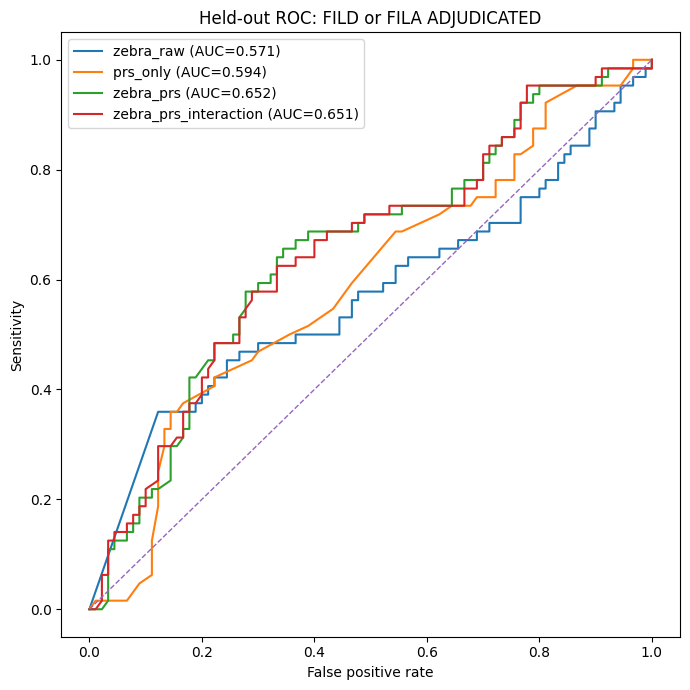

In [11]:
plt.figure(figsize=(7, 7))

for name, pred in test_pred.items():
    fpr, tpr, _ = roc_curve(y_test, pred, drop_intermediate=False)
    auc_value = roc_auc_score(y_test, pred)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("Sensitivity")
plt.title(f"Held-out ROC: {TARGET_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "roc_heldout.png", dpi=300)
plt.show()

## 11. Low-FPR ROC region

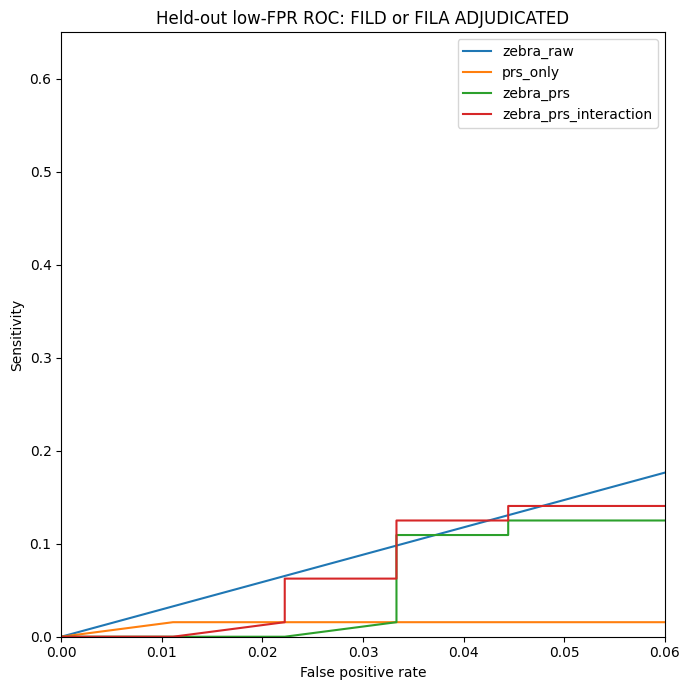

In [12]:
plt.figure(figsize=(7, 7))

for name, pred in test_pred.items():
    fpr, tpr, _ = roc_curve(y_test, pred, drop_intermediate=False)
    plt.plot(fpr, tpr, label=name)

plt.xlim(0, 0.06)
plt.ylim(0, 0.65)
plt.xlabel("False positive rate")
plt.ylabel("Sensitivity")
plt.title(f"Held-out low-FPR ROC: {TARGET_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "roc_heldout_low_fpr.png", dpi=300)
plt.show()

## 12. Calibration

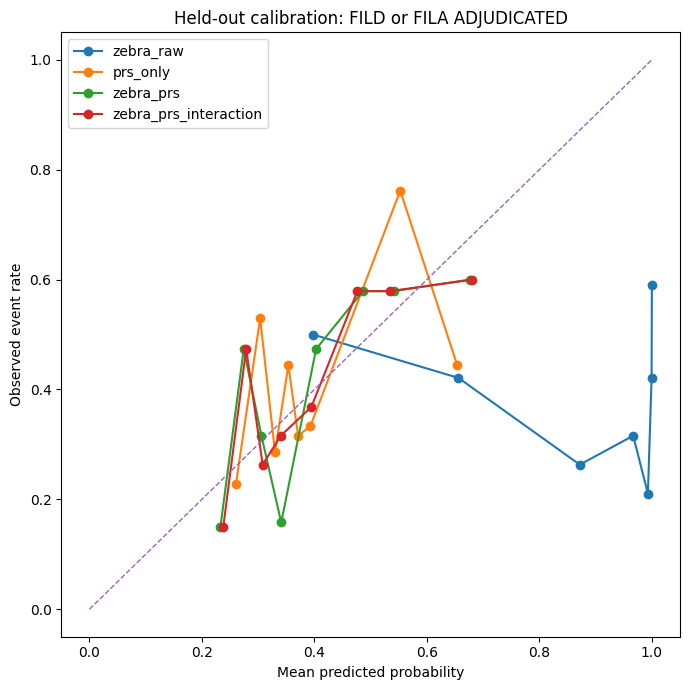

In [13]:
plt.figure(figsize=(7, 7))

for name, pred in test_pred.items():
    frac_pos, mean_pred = calibration_curve(
        y_test,
        pred,
        n_bins=8,
        strategy="quantile",
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title(f"Held-out calibration: {TARGET_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "calibration_heldout.png", dpi=300)
plt.show()

## 13. ZeBRA-stratified genetic enrichment

A global AUC can remain unchanged even if genetics is useful within a clinically ambiguous ZeBRA-risk region.

This section bins patients by ZeBRA risk and asks whether the PRS differs between fibrotic cases and controls within each stratum.

In [14]:
STRATA = pd.DataFrame({
    "target": y_test,
    "zebra": zebra_test,
    "prs": prs_test,
})

# Quantile bins based on the held-out cohort are used only descriptively here.
STRATA["zebra_decile"] = pd.qcut(
    STRATA["zebra"],
    q=10,
    labels=False,
    duplicates="drop",
)

STRAT_SUMMARY = (
    STRATA
    .groupby("zebra_decile", observed=True)
    .agg(
        n=("target", "size"),
        n_pos=("target", "sum"),
        prevalence=("target", "mean"),
        zebra_mean=("zebra", "mean"),
        prs_mean=("prs", "mean"),
    )
    .reset_index()
)

display(STRAT_SUMMARY)
STRAT_SUMMARY.to_csv(OUTDIR / "zebra_decile_summary.csv", index=False)

# Within-stratum PRS separation, reported when both classes are present.
within = []

for d, sub in STRATA.groupby("zebra_decile", observed=True):
    if sub["target"].nunique() < 2:
        auc_d = np.nan
    else:
        auc_d = roc_auc_score(sub["target"], sub["prs"])

    within.append({
        "zebra_decile": int(d),
        "n": len(sub),
        "n_pos": int(sub["target"].sum()),
        "prs_auc_within_stratum": auc_d,
        "prs_mean_cases": sub.loc[sub["target"] == 1, "prs"].mean(),
        "prs_mean_controls": sub.loc[sub["target"] == 0, "prs"].mean(),
    })

WITHIN = pd.DataFrame(within)
display(WITHIN)
WITHIN.to_csv(OUTDIR / "prs_within_zebra_deciles.csv", index=False)

,zebra_decile,n,n_pos,prevalence,zebra_mean,prs_mean
0,0,16,7,0.437500,0.369429,0.028535
1,1,15,7,0.466667,0.569573,-0.034035
2,2,15,6,0.400000,0.782281,-0.060492
3,3,16,3,0.187500,0.909918,-0.066965
4,4,15,6,0.400000,0.973567,-0.016514
5,5,15,4,0.266667,0.991729,0.025587
6,6,16,5,0.312500,0.998798,0.010381
7,7,46,26,0.565217,0.999992,-0.077762


,zebra_decile,n,n_pos,prs_auc_within_stratum,prs_mean_cases,prs_mean_controls
0,0,16,7,0.595238,0.032351,0.025567
1,1,15,7,0.428571,-0.074627,0.001483
2,2,15,6,0.611111,0.081211,-0.154960
3,3,16,3,0.794872,0.085729,-0.102203
4,4,15,6,0.638889,0.092519,-0.089202
5,5,15,4,0.636364,0.165920,-0.025442
6,6,16,5,0.563636,0.099231,-0.030006
7,7,46,26,0.584615,-0.021253,-0.151223


## 14. Optional: inspect MUC5B explicitly

This isolates the strongest known fibrotic-ILD locus if it is present in the reconstructed dosage matrix.

In [15]:
MUC5B_MATCHES = [c for c in DOSAGE.columns if c.startswith("rs35705950")]

if MUC5B_MATCHES:
    muc_col = MUC5B_MATCHES[0]
    tmp = pd.DataFrame({
        "target": y_test,
        "zebra": zebra_test,
        "prs": prs_test,
        "muc5b_dosage": DOSAGE.iloc[test_idx][muc_col].to_numpy(),
    })

    display(
        tmp.groupby("muc5b_dosage", dropna=False)
        .agg(
            n=("target", "size"),
            n_pos=("target", "sum"),
            prevalence=("target", "mean"),
            mean_zebra=("zebra", "mean"),
            mean_prs=("prs", "mean"),
        )
        .reset_index()
    )
else:
    print("rs35705950 dosage not found.")

,muc5b_dosage,n,n_pos,prevalence,mean_zebra,mean_prs
0,0.0,5,1,0.200000,0.710049,0.804417
1,1.0,34,23,0.676471,0.860658,0.345912
2,2.0,115,40,0.347826,0.864301,-0.183398


## 15. Save a compact summary

In [16]:
summary = {
    "target": TARGET_NAME,
    "n_total": int(len(DATA)),
    "n_total_positive": int(DATA["target"].sum()),
    "n_development": int(len(y_dev)),
    "n_development_positive": int(y_dev.sum()),
    "n_test": int(len(y_test)),
    "n_test_positive": int(y_test.sum()),
    "n_snp_features": int(Xg_dev.shape[1]),
    "test_auc_zebra": float(roc_auc_score(y_test, test_pred["zebra_raw"])),
    "test_auc_prs_only": float(roc_auc_score(y_test, test_pred["prs_only"])),
    "test_auc_zebra_prs": float(roc_auc_score(y_test, test_pred["zebra_prs"])),
    "test_auc_zebra_prs_interaction": float(
        roc_auc_score(y_test, test_pred["zebra_prs_interaction"])
    ),
}

with open(OUTDIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print()
print("Saved results to:", OUTDIR)

{
  "target": "FILD or FILA ADJUDICATED",
  "n_total": 615,
  "n_total_positive": 254,
  "n_development": 461,
  "n_development_positive": 190,
  "n_test": 154,
  "n_test_positive": 64,
  "n_snp_features": 169,
  "test_auc_zebra": 0.5712673611111111,
  "test_auc_prs_only": 0.5943576388888889,
  "test_auc_zebra_prs": 0.6521701388888889,
  "test_auc_zebra_prs_interaction": 0.6514756944444444
}

Saved results to: RESULTS/LOGIT_INCREMENTAL/FILD or FILA ADJUDICATED
